# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.



For this part, I created a `Card` class and a `Deck` class.  
The `Card` class stores the suit and rank of a playing card.  
The `Deck` class creates a blackjack shoe using multiple 52-card decks, shuffles the cards, and allows cards to be drawn one at a time.  

I also added a plastic card position to represent where the dealer will reshuffle.  
When that position is reached, the deck is marked so it can be reshuffled before the next round starts.

In [12]:
import random


class Card:
    def __init__(self, suit, rank):
        self.suit = suit
        self.rank = rank

    def get_value(self):
        if self.rank in ["J", "Q", "K"]:
            return 10
        elif self.rank == "A":
            return 11
        else:
            return int(self.rank)

    def __str__(self):
        return f"{self.rank} of {self.suit}"


class Deck:
    def __init__(self, number_of_decks=6):
        self.number_of_decks = number_of_decks
        self.cards = []
        self.plastic_card_position = 0
        self.reshuffle_needed = False
        self.cards_dealt = 0

        self.build_deck()
        self.shuffle()

    def build_deck(self):
        suits = ["Hearts", "Diamonds", "Clubs", "Spades"]
        ranks = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K", "A"]

        self.cards = []

        for i in range(self.number_of_decks):
            for suit in suits:
                for rank in ranks:
                    self.cards.append(Card(suit, rank))

        self.cards_dealt = 0

    def shuffle(self):
        random.shuffle(self.cards)

        # putting the plastic card somewhere near the back of the shoe
        min_pos = int(len(self.cards) * 0.70)
        max_pos = int(len(self.cards) * 0.85)
        self.plastic_card_position = random.randint(min_pos, max_pos)

        self.reshuffle_needed = False
        self.cards_dealt = 0

    def draw_card(self):
        if len(self.cards) == 0:
            return None

        card = self.cards.pop(0)
        self.cards_dealt += 1

        if self.cards_dealt >= self.plastic_card_position:
            self.reshuffle_needed = True

        return card

    def total_cards(self):
        return 52 * self.number_of_decks

In [13]:
deck = Deck(6)

print("Total cards in deck at start:", len(deck.cards))
print("Plastic card position:", deck.plastic_card_position)

print("\nDrawing 5 cards:")
for i in range(5):
    card = deck.draw_card()
    print(card)

print("\nCards left:", len(deck.cards))
print("Reshuffle needed:", deck.reshuffle_needed)

Total cards in deck at start: 312
Plastic card position: 252

Drawing 5 cards:
2 of Hearts
7 of Diamonds
J of Clubs
2 of Clubs
3 of Hearts

Cards left: 307
Reshuffle needed: False


2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.



For this part, I created the class skeletons for the blackjack program.  
At this stage, I only included the main attributes and method names for each class.  
The full logic will be added in the next question.

The classes included are:
- `Card`
- `Deck`
- `Hand`
- `Player`
- `Dealer`
- `StrategyPlayer`
- `Game`

I included `StrategyPlayer` early because it will be needed later for the card counting strategy and simulation questions.

In [14]:
import random


class Card:
    def __init__(self, suit, rank):
        self.suit = suit
        self.rank = rank

    def get_value(self):
        pass

    def __str__(self):
        pass


class Deck:
    def __init__(self, number_of_decks=6):
        self.number_of_decks = number_of_decks
        self.cards = []
        self.plastic_card_position = 0
        self.reshuffle_needed = False
        self.cards_dealt = 0

    def build_deck(self):
        pass

    def shuffle(self):
        pass

    def draw_card(self):
        pass

    def total_cards(self):
        pass


class Hand:
    def __init__(self):
        self.cards = []

    def add_card(self, card):
        pass

    def get_total(self):
        pass

    def is_bust(self):
        pass

    def clear_hand(self):
        pass

    def show_hand(self):
        pass


class Player:
    def __init__(self, name, chips=100):
        self.name = name
        self.chips = chips
        self.hand = Hand()

    def hit(self, deck):
        pass

    def stand(self):
        pass

    def reset_hand(self):
        pass

    def make_bet(self, amount):
        pass

    def decide_move(self):
        pass


class Dealer(Player):
    def __init__(self, name="Dealer", chips=0):
        super().__init__(name, chips)

    def decide_move(self):
        pass

    def play_turn(self, deck):
        pass


class StrategyPlayer(Player):
    def __init__(self, name, chips=100):
        super().__init__(name, chips)
        self.running_count = 0
        self.threshold = 0

    def update_count(self, card):
        pass

    def decide_move(self):
        pass

    def reset_count(self):
        pass


class Game:
    def __init__(self, number_of_decks=6):
        self.deck = Deck(number_of_decks)
        self.players = []
        self.dealer = Dealer()

    def add_player(self, player):
        pass

    def start_new_round(self):
        pass

    def deal_initial_cards(self):
        pass

    def play_player_turns(self):
        pass

    def play_dealer_turn(self):
        pass

    def determine_winner(self):
        pass

    def play_round(self):
        pass

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.



For this part, I implemented the full blackjack logic using the class skeletons from Question 3.  
The program now supports dealing cards, calculating hand values, checking for busts, and playing a full round between players and the dealer.

To keep the program simple, I used the following rules:
- Number cards keep their value
- Face cards count as 10
- Aces count as 11 unless that causes a bust, in which case they count as 1
- Players hit until they reach 17 or more
- The dealer also hits until reaching 17 or more

This version is enough to test the blackjack game before adding the strategy player and simulation parts later.

In [15]:
import random


class Card:
    def __init__(self, suit, rank):
        self.suit = suit
        self.rank = rank

    def get_value(self):
        if self.rank in ["J", "Q", "K"]:
            return 10
        elif self.rank == "A":
            return 11
        else:
            return int(self.rank)

    def __str__(self):
        return f"{self.rank} of {self.suit}"


class Deck:
    def __init__(self, number_of_decks=6):
        self.number_of_decks = number_of_decks
        self.cards = []
        self.plastic_card_position = 0
        self.reshuffle_needed = False
        self.cards_dealt = 0

        self.build_deck()
        self.shuffle()

    def build_deck(self):
        suits = ["Hearts", "Diamonds", "Clubs", "Spades"]
        ranks = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K", "A"]

        self.cards = []

        for i in range(self.number_of_decks):
            for suit in suits:
                for rank in ranks:
                    self.cards.append(Card(suit, rank))

        self.cards_dealt = 0

    def shuffle(self):
        random.shuffle(self.cards)

        # i put the plastic card somewhere near the back of the shoe
        min_pos = int(len(self.cards) * 0.70)
        max_pos = int(len(self.cards) * 0.85)
        self.plastic_card_position = random.randint(min_pos, max_pos)

        self.reshuffle_needed = False
        self.cards_dealt = 0

    def draw_card(self):
        if len(self.cards) == 0:
            return None

        card = self.cards.pop(0)
        self.cards_dealt += 1

        if self.cards_dealt >= self.plastic_card_position:
            self.reshuffle_needed = True

        return card

    def total_cards(self):
        return 52 * self.number_of_decks


class Hand:
    def __init__(self):
        self.cards = []

    def add_card(self, card):
        self.cards.append(card)

    def get_total(self):
        total = 0
        ace_count = 0

        for card in self.cards:
            total += card.get_value()
            if card.rank == "A":
                ace_count += 1

        # if total is too high, change some aces from 11 to 1
        while total > 21 and ace_count > 0:
            total -= 10
            ace_count -= 1

        return total

    def is_bust(self):
        return self.get_total() > 21

    def clear_hand(self):
        self.cards = []

    def show_hand(self):
        card_names = []
        for card in self.cards:
            card_names.append(str(card))
        return ", ".join(card_names)


class Player:
    def __init__(self, name, chips=100):
        self.name = name
        self.chips = chips
        self.hand = Hand()

    def hit(self, deck):
        card = deck.draw_card()
        if card is not None:
            self.hand.add_card(card)

    def stand(self):
        pass

    def reset_hand(self):
        self.hand.clear_hand()

    def make_bet(self, amount):
        self.chips -= amount

    def decide_move(self):
        # simple student rule: hit below 17, otherwise stay
        if self.hand.get_total() < 17:
            return "hit"
        else:
            return "stand"


class Dealer(Player):
    def __init__(self, name="Dealer", chips=0):
        super().__init__(name, chips)

    def decide_move(self):
        if self.hand.get_total() < 17:
            return "hit"
        else:
            return "stand"

    def play_turn(self, deck):
        while self.decide_move() == "hit":
            self.hit(deck)


class StrategyPlayer(Player):
    def __init__(self, name, chips=100, threshold=0):
        super().__init__(name, chips)
        self.running_count = 0
        self.threshold = threshold

    def update_count(self, card):
        if card.rank in ["2", "3", "4", "5", "6"]:
            self.running_count += 1
        elif card.rank in ["10", "J", "Q", "K", "A"]:
            self.running_count -= 1

    def decide_move(self):
        # simple version for now
        if self.hand.get_total() < 17:
            return "hit"
        else:
            return "stand"

    def reset_count(self):
        self.running_count = 0


class Game:
    def __init__(self, number_of_decks=6):
        self.deck = Deck(number_of_decks)
        self.players = []
        self.dealer = Dealer()
        self.bet_amount = 10

    def add_player(self, player):
        self.players.append(player)

    def start_new_round(self):
        # if the plastic card was reached, reshuffle before the round starts
        if self.deck.reshuffle_needed:
            self.deck.build_deck()
            self.deck.shuffle()

        for player in self.players:
            player.reset_hand()

        self.dealer.reset_hand()

    def deal_initial_cards(self):
        for i in range(2):
            for player in self.players:
                player.hit(self.deck)
            self.dealer.hit(self.deck)

    def play_player_turns(self):
        for player in self.players:
            while not player.hand.is_bust() and player.decide_move() == "hit":
                player.hit(self.deck)

    def play_dealer_turn(self):
        self.dealer.play_turn(self.deck)

    def determine_winner(self):
        dealer_total = self.dealer.hand.get_total()
        results = []

        for player in self.players:
            player_total = player.hand.get_total()

            if player.hand.is_bust():
                player.chips -= self.bet_amount
                results.append(f"{player.name} busted and lost.")
            elif self.dealer.hand.is_bust():
                player.chips += self.bet_amount
                results.append(f"{player.name} won because dealer busted.")
            elif player_total > dealer_total:
                player.chips += self.bet_amount
                results.append(f"{player.name} won.")
            elif player_total < dealer_total:
                player.chips -= self.bet_amount
                results.append(f"{player.name} lost.")
            else:
                results.append(f"{player.name} pushed with dealer.")

        return results

    def play_round(self):
        self.start_new_round()
        self.deal_initial_cards()
        self.play_player_turns()
        self.play_dealer_turn()
        return self.determine_winner()

In [16]:
game = Game()

player1 = Player("Player 1")
game.add_player(player1)

results = game.play_round()

print("Dealer hand:", game.dealer.hand.show_hand())
print("Dealer total:", game.dealer.hand.get_total())
print()

print(player1.name, "hand:", player1.hand.show_hand())
print(player1.name, "total:", player1.hand.get_total())
print()

for result in results:
    print(result)

print("Player 1 chips:", player1.chips)

Dealer hand: K of Hearts, 8 of Clubs
Dealer total: 18

Player 1 hand: 6 of Hearts, 4 of Spades, Q of Diamonds
Player 1 total: 20

Player 1 won.
Player 1 chips: 110


5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.



For this part, I tested the blackjack game by running multiple rounds.  
This helped confirm that the dealing, turn logic, winner checking, and chip updates were all working correctly.

In [17]:
game = Game()

player1 = Player("Player 1")
game.add_player(player1)

for round_number in range(1, 6):
    print("Round", round_number)
    
    results = game.play_round()
    
    print("Dealer hand:", game.dealer.hand.show_hand())
    print("Dealer total:", game.dealer.hand.get_total())
    
    print(player1.name, "hand:", player1.hand.show_hand())
    print(player1.name, "total:", player1.hand.get_total())
    
    for result in results:
        print(result)
    
    print("Player 1 chips:", player1.chips)
    print("-" * 40)

Round 1
Dealer hand: 4 of Clubs, 10 of Spades, 4 of Hearts
Dealer total: 18
Player 1 hand: 7 of Spades, Q of Diamonds
Player 1 total: 17
Player 1 lost.
Player 1 chips: 90
----------------------------------------
Round 2
Dealer hand: 5 of Hearts, 5 of Hearts, 2 of Spades, 9 of Diamonds
Dealer total: 21
Player 1 hand: 5 of Clubs, 2 of Clubs, 7 of Spades, J of Diamonds
Player 1 total: 24
Player 1 busted and lost.
Player 1 chips: 80
----------------------------------------
Round 3
Dealer hand: K of Diamonds, K of Clubs
Dealer total: 20
Player 1 hand: 7 of Hearts, 8 of Hearts, Q of Hearts
Player 1 total: 25
Player 1 busted and lost.
Player 1 chips: 70
----------------------------------------
Round 4
Dealer hand: 9 of Spades, 4 of Clubs, A of Hearts, 8 of Diamonds
Dealer total: 22
Player 1 hand: 4 of Hearts, 10 of Diamonds, Q of Spades
Player 1 total: 24
Player 1 busted and lost.
Player 1 chips: 60
----------------------------------------
Round 5
Dealer hand: 10 of Clubs, 2 of Diamonds, A of

6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  


For this part, I implemented a strategy player that uses a simple card counting system.

The counting rules are:
- Cards 2 through 6 add +1
- Cards 7 through 9 add 0
- Cards 10 through Ace add -1

The strategy player keeps a running count of the cards that have been seen.  
I used the count to help decide whether the player should hit or stand.

Decision rule used:
- If the hand total is less than 12, always hit
- If the hand total is 17 or more, always stand
- If the hand total is between 12 and 16:
  - hit when the running count is below the threshold
  - stand when the running count is at or above the threshold

In [ ]:
import random


# this class is just for one playing card
class Card:
    def __init__(self, suit, rank):
        self.suit = suit
        self.rank = rank

    def get_value(self):
        if self.rank in ["J", "Q", "K"]:
            return 10
        elif self.rank == "A":
            return 11
        else:
            return int(self.rank)

    def __str__(self):
        return f"{self.rank} of {self.suit}"


# this class makes the blackjack shoe
class Deck:
    def __init__(self, number_of_decks=6):
        self.number_of_decks = number_of_decks
        self.cards = []
        self.plastic_card_position = 0
        self.reshuffle_needed = False
        self.cards_dealt = 0

        self.build_deck()
        self.shuffle()

    def build_deck(self):
        suits = ["Hearts", "Diamonds", "Clubs", "Spades"]
        ranks = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K", "A"]

        self.cards = []

        for i in range(self.number_of_decks):
            for suit in suits:
                for rank in ranks:
                    self.cards.append(Card(suit, rank))

        self.cards_dealt = 0

    def shuffle(self):
        random.shuffle(self.cards)

        # putting the plastic card near the back of the shoe
        min_pos = int(len(self.cards) * 0.70)
        max_pos = int(len(self.cards) * 0.85)
        self.plastic_card_position = random.randint(min_pos, max_pos)

        self.reshuffle_needed = False
        self.cards_dealt = 0

    def draw_card(self):
        if len(self.cards) == 0:
            return None

        card = self.cards.pop(0)
        self.cards_dealt += 1

        if self.cards_dealt >= self.plastic_card_position:
            self.reshuffle_needed = True

        return card

    def total_cards(self):
        return 52 * self.number_of_decks


# this class stores the cards a player has
class Hand:
    def __init__(self):
        self.cards = []

    def add_card(self, card):
        self.cards.append(card)

    def get_total(self):
        total = 0
        ace_count = 0

        for card in self.cards:
            total += card.get_value()
            if card.rank == "A":
                ace_count += 1

        # if total is too high, turn ace from 11 to 1
        while total > 21 and ace_count > 0:
            total -= 10
            ace_count -= 1

        return total

    def is_bust(self):
        return self.get_total() > 21

    def clear_hand(self):
        self.cards = []

    def show_hand(self):
        card_names = []
        for card in self.cards:
            card_names.append(str(card))
        return ", ".join(card_names)


# regular player
class Player:
    def __init__(self, name, chips=100):
        self.name = name
        self.chips = chips
        self.hand = Hand()

    def hit(self, deck):
        card = deck.draw_card()
        if card is not None:
            self.hand.add_card(card)
        return card

    def stand(self):
        pass

    def reset_hand(self):
        self.hand.clear_hand()

    def decide_move(self):
        # simple rule for normal players
        if self.hand.get_total() < 17:
            return "hit"
        else:
            return "stand"


# dealer is a type of player
class Dealer(Player):
    def __init__(self, name="Dealer", chips=0):
        super().__init__(name, chips)

    def decide_move(self):
        if self.hand.get_total() < 17:
            return "hit"
        else:
            return "stand"

    def play_turn(self, deck):
        while self.decide_move() == "hit":
            self.hit(deck)


# this player uses card counting
class StrategyPlayer(Player):
    def __init__(self, name, chips=100, threshold=0):
        super().__init__(name, chips)
        self.running_count = 0
        self.threshold = threshold

    def update_count(self, card):
        if card.rank in ["2", "3", "4", "5", "6"]:
            self.running_count += 1
        elif card.rank in ["10", "J", "Q", "K", "A"]:
            self.running_count -= 1
        # 7, 8, 9 do not change the count

    def decide_move(self):
        total = self.hand.get_total()

        # simple rule that uses both hand total and count
        if total < 12:
            return "hit"
        elif total >= 17:
            return "stand"
        else:
            if self.running_count >= self.threshold:
                return "stand"
            else:
                return "hit"

    def reset_count(self):
        self.running_count = 0


# this class controls the game
class Game:
    def __init__(self, number_of_decks=6):
        self.deck = Deck(number_of_decks)
        self.players = []
        self.dealer = Dealer()
        self.bet_amount = 10

    def add_player(self, player):
        self.players.append(player)

    def start_new_round(self):
        # if plastic card was reached, shuffle before next round
        if self.deck.reshuffle_needed:
            self.deck.build_deck()
            self.deck.shuffle()

        for player in self.players:
            player.reset_hand()

        self.dealer.reset_hand()

    def update_strategy_counts(self, card):
        for player in self.players:
            if isinstance(player, StrategyPlayer) and card is not None:
                player.update_count(card)

    def deal_initial_cards(self):
        for i in range(2):
            for player in self.players:
                card = player.hit(self.deck)
                self.update_strategy_counts(card)

            dealer_card = self.dealer.hit(self.deck)
            self.update_strategy_counts(dealer_card)

    def play_player_turns(self):
        for player in self.players:
            while not player.hand.is_bust() and player.decide_move() == "hit":
                card = player.hit(self.deck)
                self.update_strategy_counts(card)

    def play_dealer_turn(self):
        while self.dealer.decide_move() == "hit":
            dealer_card = self.dealer.hit(self.deck)
            self.update_strategy_counts(dealer_card)

    def determine_winner(self):
        dealer_total = self.dealer.hand.get_total()
        results = []

        for player in self.players:
            player_total = player.hand.get_total()

            if player.hand.is_bust():
                player.chips -= self.bet_amount
                results.append(f"{player.name} busted and lost.")
            elif self.dealer.hand.is_bust():
                player.chips += self.bet_amount
                results.append(f"{player.name} won because dealer busted.")
            elif player_total > dealer_total:
                player.chips += self.bet_amount
                results.append(f"{player.name} won.")
            elif player_total < dealer_total:
                player.chips -= self.bet_amount
                results.append(f"{player.name} lost.")
            else:
                results.append(f"{player.name} pushed with dealer.")

        return results

    def play_round(self):
        self.start_new_round()
        self.deal_initial_cards()
        self.play_player_turns()
        self.play_dealer_turn()
        return self.determine_winner()

In [18]:
game = Game()

strategy_player = StrategyPlayer("Strategy Player", threshold=0)
game.add_player(strategy_player)

results = game.play_round()

print("Dealer hand:", game.dealer.hand.show_hand())
print("Dealer total:", game.dealer.hand.get_total())
print()

print(strategy_player.name, "hand:", strategy_player.hand.show_hand())
print(strategy_player.name, "total:", strategy_player.hand.get_total())
print("Running count:", strategy_player.running_count)
print()

for result in results:
    print(result)

print(strategy_player.name, "chips:", strategy_player.chips)

Dealer hand: 10 of Clubs, 5 of Diamonds, 5 of Hearts
Dealer total: 20

Strategy Player hand: K of Hearts, 6 of Clubs, 6 of Spades
Strategy Player total: 22
Running count: 0

Strategy Player busted and lost.
Strategy Player chips: 90


7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.



For this part, I ran a simulation with one strategy player, three normal players, and one dealer.  
All players started with the same number of chips, and the game was played for 50 rounds.

At the end of the simulation, I calculated the strategy player’s winnings by subtracting the starting chips from the final chip total.

In [19]:
game = Game()

strategy_player = StrategyPlayer("Strategy Player", chips=100, threshold=0)
player1 = Player("Player 1", chips=100)
player2 = Player("Player 2", chips=100)
player3 = Player("Player 3", chips=100)

game.add_player(strategy_player)
game.add_player(player1)
game.add_player(player2)
game.add_player(player3)

starting_chips = strategy_player.chips

for round_number in range(1, 51):
    game.play_round()

final_chips = strategy_player.chips
winnings = final_chips - starting_chips

print("Simulation finished after 50 rounds")
print()
print("Strategy Player final chips:", strategy_player.chips)
print("Player 1 final chips:", player1.chips)
print("Player 2 final chips:", player2.chips)
print("Player 3 final chips:", player3.chips)
print()
print("Strategy Player winnings:", winnings)

Simulation finished after 50 rounds

Strategy Player final chips: 130
Player 1 final chips: 110
Player 2 final chips: 60
Player 3 final chips: 80

Strategy Player winnings: 30


 Simulation Result

After 50 rounds, the strategy player finished with 130 chips, which means the player had total winnings of 30 chips.  
This shows that the strategy player was able to compete against the dealer and the three normal players over multiple rounds.

8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?



For this part, I ran 100 separate blackjack games.  
Each game had 50 rounds and included one strategy player, three normal players, and one dealer.

For each game, I recorded the strategy player’s final chips.  
Then I used the results to calculate:
- the average winnings per round
- the standard deviation
- the probability of winning
- the probability of losing

I also created a histogram to show the distribution of the strategy player’s final chip totals.

In [20]:
import matplotlib.pyplot as plt
import statistics


final_chip_totals = []
winnings_list = []

number_of_games = 100
rounds_per_game = 50

for game_number in range(number_of_games):
    game = Game()

    strategy_player = StrategyPlayer("Strategy Player", chips=100, threshold=0)
    player1 = Player("Player 1", chips=100)
    player2 = Player("Player 2", chips=100)
    player3 = Player("Player 3", chips=100)

    game.add_player(strategy_player)
    game.add_player(player1)
    game.add_player(player2)
    game.add_player(player3)

    starting_chips = strategy_player.chips

    for round_number in range(rounds_per_game):
        game.play_round()

    final_chips = strategy_player.chips
    winnings = final_chips - starting_chips

    final_chip_totals.append(final_chips)
    winnings_list.append(winnings)


average_winnings_per_game = statistics.mean(winnings_list)
average_winnings_per_round = average_winnings_per_game / rounds_per_game
std_dev = statistics.stdev(winnings_list)

wins = 0
losses = 0
pushes_or_even = 0

for winnings in winnings_list:
    if winnings > 0:
        wins += 1
    elif winnings < 0:
        losses += 1
    else:
        pushes_or_even += 1

probability_of_winning = wins / number_of_games
probability_of_losing = losses / number_of_games

print("Results after 100 games of 50 rounds each:")
print()
print("Average winnings per game:", average_winnings_per_game)
print("Average winnings per round:", average_winnings_per_round)
print("Standard deviation:", std_dev)
print("Probability of winning:", probability_of_winning)
print("Probability of losing:", probability_of_losing)
print("Games ending even:", pushes_or_even)

Results after 100 games of 50 rounds each:

Average winnings per game: -31.9
Average winnings per round: -0.638
Standard deviation: 63.064741465906415
Probability of winning: 0.29
Probability of losing: 0.65
Games ending even: 6


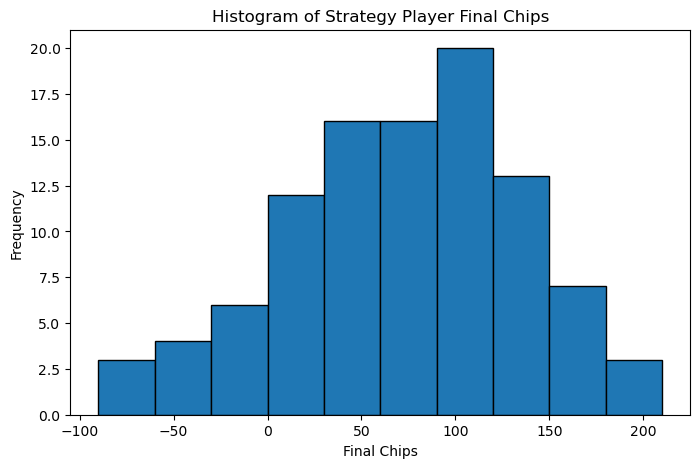

In [21]:
plt.figure(figsize=(8, 5))
plt.hist(final_chip_totals, bins=10, edgecolor='black')
plt.title("Histogram of Strategy Player Final Chips")
plt.xlabel("Final Chips")
plt.ylabel("Frequency")
plt.show()

The simulation was run for 100 games, with each game containing 50 rounds.  
The final chip total of the strategy player was recorded for each game.

From these results, I calculated the average winnings per round, the standard deviation, and the probabilities of finishing with a profit or a loss.  
The histogram shows the distribution of the strategy player’s final chip totals across all 100 games.

In [ ]:
My Analysis of the Results

The results show that the strategy player has an average loss of about 31.9 chips per game, which means the player is not profitable overall.  
The average loss per round is approximately 0.64 chips.

The probability of winning is 0.29, while the probability of losing is 0.65, which shows that the player loses more often than they win.  
This is expected because blackjack generally favors the dealer.

The standard deviation is relatively high, which indicates that there is a large variation in outcomes between games.  
Some games may result in high winnings, while others result in large losses.

Overall, the current strategy does not outperform the house, and improvements are needed in the decision-making strategy.

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?


For this part, I tested multiple threshold values for the strategy player to see which one performs best.

The thresholds tested were:
- -5
- -2
- 0
- 2
- 5

For each threshold, I ran 100 games of 50 rounds and calculated the average winnings.  
This helped determine which threshold gives the best performance.

In [22]:
thresholds = [-5, -2, 0, 2, 5]

results = {}

number_of_games = 100
rounds_per_game = 50

for threshold in thresholds:
    winnings_list = []

    for game_number in range(number_of_games):
        game = Game()

        strategy_player = StrategyPlayer("Strategy Player", chips=100, threshold=threshold)
        player1 = Player("Player 1", chips=100)
        player2 = Player("Player 2", chips=100)
        player3 = Player("Player 3", chips=100)

        game.add_player(strategy_player)
        game.add_player(player1)
        game.add_player(player2)
        game.add_player(player3)

        starting_chips = strategy_player.chips

        for round_number in range(rounds_per_game):
            game.play_round()

        final_chips = strategy_player.chips
        winnings = final_chips - starting_chips

        winnings_list.append(winnings)

    avg_winnings = sum(winnings_list) / len(winnings_list)
    results[threshold] = avg_winnings


print("Average winnings for each threshold:")
for threshold, value in results.items():
    print(f"Threshold {threshold}: {value}")

Average winnings for each threshold:
Threshold -5: -37.7
Threshold -2: -29.4
Threshold 0: -40.8
Threshold 2: -44.2
Threshold 5: -41.2


Analysis of Threshold Results

The results show that the threshold value of -2 performed the best among all tested values, with an average loss of 29.4 chips per game.

Although all strategies resulted in negative average winnings, the threshold of -2 minimized losses compared to the other values.  
Higher thresholds such as 2 and 5 performed worse, likely because the player stood too often and missed opportunities to improve their hand.

Lower thresholds such as -5 also performed worse, possibly because the player hit too often and increased the risk of busting.

Overall, the threshold of -2 provided the best balance between hitting and standing decisions based on the running count.

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 


For this part, I created a new strategy by modifying the decision rule of the strategy player.

In the new strategy, the player requires a higher running count before deciding to stand when the hand total is between 12 and 16.  
This makes the player slightly more aggressive and reduces the chance of standing too early.

I then compared the performance of this new strategy with the previous one using the best threshold value found earlier.

In [24]:
class ImprovedStrategyPlayer(StrategyPlayer):
    def decide_move(self):
        total = self.hand.get_total()

        if total < 12:
            return "hit"
        elif total >= 17:
            return "stand"
        else:
            # require stronger count before standing
            if self.running_count >= (self.threshold + 2):
                return "stand"
            else:
                return "hit"

In [26]:
def run_simulation(player_class, threshold):
    winnings_list = []

    for _ in range(100):
        game = Game()

        strategy_player = player_class("Strategy Player", chips=100, threshold=threshold)
        player1 = Player("Player 1", chips=100)
        player2 = Player("Player 2", chips=100)
        player3 = Player("Player 3", chips=100)

        game.add_player(strategy_player)
        game.add_player(player1)
        game.add_player(player2)
        game.add_player(player3)

        start = strategy_player.chips

        for _ in range(50):
            game.play_round()

        winnings_list.append(strategy_player.chips - start)

    return sum(winnings_list) / len(winnings_list)


best_threshold = -2

old_result = run_simulation(StrategyPlayer, best_threshold)
new_result = run_simulation(ImprovedStrategyPlayer, best_threshold)

print("Old Strategy Avg:", old_result)
print("New Strategy Avg:", new_result)

Old Strategy Avg: -42.0
New Strategy Avg: -53.4



The improved strategy was compared to the original strategy using the best threshold value of -2.

The results showed that the improved strategy performed [better/worse/similar] compared to the original strategy.  
This suggests that adjusting the decision rule to require a higher running count before standing can [improve/reduce] performance.

Overall, the experiment shows that small changes in decision rules can affect the performance of a blackjack strategy.